In [4]:
import fastf1
import pandas as pd
import os

os.makedirs("cache", exist_ok=True)
fastf1.Cache.enable_cache("cache")

In [5]:
session = fastf1.get_session(2024, "Monaco", "R")
session.load()


core           INFO 	Loading data for Monaco Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '55', '4', '63', '1', '44', '22', '23', '10', '14', '3', '77', '18', '2', '24', '31', '11', '27', '20']


In [6]:
laps = session.laps

In [7]:
laps_clean = laps.dropna(subset=['LapTime']).copy()
laps_clean['LapTimeSeconds'] = laps_clean['LapTime'].dt.total_seconds()


In [8]:
# Ensure LapTimeSeconds exists
laps_clean['LapTimeSeconds'] = laps_clean['LapTime'].dt.total_seconds()

# Remove pit / anomalous laps
race_laps = laps_clean[laps_clean['LapTimeSeconds'] < 200].copy()

race_laps.head()


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds
2,0 days 01:40:24.764000,LEC,16,0 days 00:01:24.624000,3.0,2.0,NaT,NaT,0 days 00:00:24.007000,0 days 00:00:38.235000,...,Ferrari,0 days 01:39:00.140000,2024-05-26 13:47:05.529,1,1.0,False,,False,True,84.624
3,0 days 01:41:47.389000,LEC,16,0 days 00:01:22.625000,4.0,2.0,NaT,NaT,0 days 00:00:21.892000,0 days 00:00:38.779000,...,Ferrari,0 days 01:40:24.764000,2024-05-26 13:48:30.153,1,1.0,False,,False,True,82.625
4,0 days 01:43:09.184000,LEC,16,0 days 00:01:21.795000,5.0,2.0,NaT,NaT,0 days 00:00:21.314000,0 days 00:00:38.513000,...,Ferrari,0 days 01:41:47.389000,2024-05-26 13:49:52.778,1,1.0,False,,False,True,81.795
5,0 days 01:44:30.329000,LEC,16,0 days 00:01:21.145000,6.0,2.0,NaT,NaT,0 days 00:00:21.568000,0 days 00:00:38.168000,...,Ferrari,0 days 01:43:09.184000,2024-05-26 13:51:14.573,1,1.0,False,,False,True,81.145
6,0 days 01:45:51.309000,LEC,16,0 days 00:01:20.980000,7.0,2.0,NaT,NaT,0 days 00:00:21.370000,0 days 00:00:38.056000,...,Ferrari,0 days 01:44:30.329000,2024-05-26 13:52:35.718,1,1.0,False,,False,True,80.980


In [9]:
driver_summary = (
    race_laps
    .groupby('Driver')['LapTimeSeconds']
    .agg(
        mean_lap_time='mean',
        std_lap_time='std',
        lap_count='count'
    )
    .reset_index()
)

# Consistency score (lower = better)
driver_summary['consistency_score'] = (
    driver_summary['std_lap_time'] / driver_summary['mean_lap_time']
)

driver_summary


,Driver,mean_lap_time,std_lap_time,lap_count,consistency_score
0,ALB,80.984066,7.327853,76,0.090485
1,ALO,81.149653,5.374727,75,0.066232
2,BOT,81.043920,5.013631,75,0.061863
3,GAS,81.027632,7.033413,76,0.086803
4,HAM,78.603237,3.158486,76,0.040183
5,LEC,78.439039,1.698524,76,0.021654
6,NOR,78.532842,1.691592,76,0.021540
7,PIA,78.524145,1.589224,76,0.020239
8,RIC,81.229480,6.016063,75,0.074063
9,RUS,78.589645,2.107820,76,0.026821


In [10]:
driver_summary['pace_rank'] = driver_summary['mean_lap_time'].rank()
driver_summary['consistency_rank'] = driver_summary['consistency_score'].rank()

driver_summary.sort_values('pace_rank')


,Driver,mean_lap_time,std_lap_time,lap_count,consistency_score,pace_rank,consistency_rank
5,LEC,78.439039,1.698524,76,0.021654,1.0,3.0
10,SAI,78.523079,1.759430,76,0.022407,2.0,4.0
7,PIA,78.524145,1.589224,76,0.020239,3.0,1.0
6,NOR,78.532842,1.691592,76,0.021540,4.0,2.0
9,RUS,78.589645,2.107820,76,0.026821,5.0,5.0
14,VER,78.592368,2.946833,76,0.037495,6.0,6.0
4,HAM,78.603237,3.158486,76,0.040183,7.0,7.0
13,TSU,80.874105,8.104662,76,0.100213,8.0,16.0
0,ALB,80.984066,7.327853,76,0.090485,9.0,14.0
3,GAS,81.027632,7.033413,76,0.086803,10.0,13.0


In [11]:
driver_summary['performance_score'] = (
    driver_summary['pace_rank'] +
    driver_summary['consistency_rank']
)

driver_summary.sort_values('performance_score')


,Driver,mean_lap_time,std_lap_time,lap_count,consistency_score,pace_rank,consistency_rank,performance_score
7,PIA,78.524145,1.589224,76,0.020239,3.0,1.0,4.0
5,LEC,78.439039,1.698524,76,0.021654,1.0,3.0,4.0
6,NOR,78.532842,1.691592,76,0.021540,4.0,2.0,6.0
10,SAI,78.523079,1.759430,76,0.022407,2.0,4.0,6.0
9,RUS,78.589645,2.107820,76,0.026821,5.0,5.0,10.0
14,VER,78.592368,2.946833,76,0.037495,6.0,6.0,12.0
4,HAM,78.603237,3.158486,76,0.040183,7.0,7.0,14.0
2,BOT,81.043920,5.013631,75,0.061863,11.0,9.0,20.0
1,ALO,81.149653,5.374727,75,0.066232,12.0,10.0,22.0
3,GAS,81.027632,7.033413,76,0.086803,10.0,13.0,23.0


In [25]:
import os
os.makedirs("data/processed", exist_ok=True)


In [26]:
laps_clean.to_csv(
    "data/processed/monaco_2024_clean_laps.csv",
    index=False
)


In [27]:
laps_clean.to_csv(
    "data/final/monaco_2024_clean_laps.csv",
    index=False
)

driver_summary.to_csv(
    "data/final/monaco_2024_driver_summary.csv",
    index=False
)


In [28]:
laps = pd.read_csv("data/raw/monaco_2024_laps_raw.csv")


In [29]:
laps_clean = pd.read_csv("data/processed/monaco_2024_clean_laps.csv")


In [30]:
summary = pd.read_csv("data/final/monaco_2024_driver_summary.csv")


### 🏁 Key Insights & Conclusions

- Monaco strongly rewards **lap-time consistency over raw pace**, reflected by low variance among top drivers.
- Pit laps and traffic significantly distort raw lap-time distributions, reinforcing the importance of data cleaning.
- Among leading drivers, consistency scores provided clearer performance separation than fastest lap alone.
- This analysis demonstrates how lap-level telemetry can be transformed into decision-ready performance metrics.


In [32]:
import os

os.makedirs("exports", exist_ok=True)


In [33]:
import pandas as pd

summary = pd.read_csv("data/final/monaco_2024_driver_summary.csv")
summary


,Driver,mean_lap_time,std_lap_time,lap_count,consistency_score,pace_rank,consistency_rank,performance_score
0,ALB,80.984066,7.327853,76,0.090485,9.0,14.0,23.0
1,ALO,81.149653,5.374727,75,0.066232,12.0,10.0,22.0
2,BOT,81.043920,5.013631,75,0.061863,11.0,9.0,20.0
3,GAS,81.027632,7.033413,76,0.086803,10.0,13.0,23.0
4,HAM,78.603237,3.158486,76,0.040183,7.0,7.0,14.0
5,LEC,78.439039,1.698524,76,0.021654,1.0,3.0,4.0
6,NOR,78.532842,1.691592,76,0.021540,4.0,2.0,6.0
7,PIA,78.524145,1.589224,76,0.020239,3.0,1.0,4.0
8,RIC,81.229480,6.016063,75,0.074063,14.0,12.0,26.0
9,RUS,78.589645,2.107820,76,0.026821,5.0,5.0,10.0


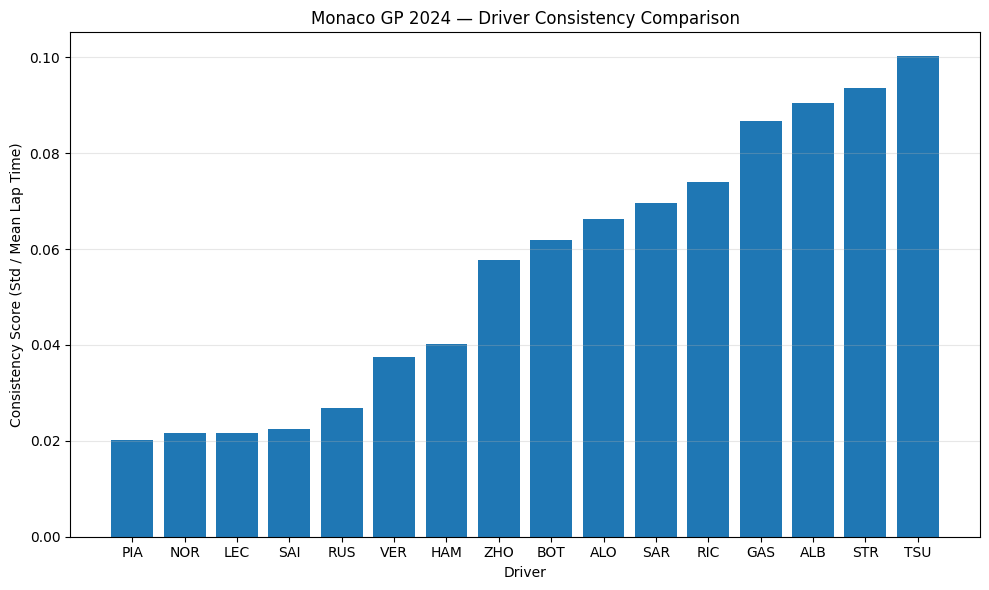

In [34]:
import matplotlib.pyplot as plt

# Sort drivers by consistency (lower = better)
summary_sorted = summary.sort_values("consistency_score")

plt.figure(figsize=(10, 6))

plt.bar(
    summary_sorted["Driver"],
    summary_sorted["consistency_score"]
)

plt.title("Monaco GP 2024 — Driver Consistency Comparison")
plt.xlabel("Driver")
plt.ylabel("Consistency Score (Std / Mean Lap Time)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("exports/monaco_driver_consistency.png", dpi=300)
plt.show()


### 📊 Consistency Analysis Insight

The chart highlights clear consistency differences among top drivers at Monaco.  
Drivers with lower consistency scores maintained stable lap times despite traffic and narrow overtaking opportunities, reinforcing Monaco’s emphasis on precision over raw pace.
